# Step 4: OCV-SOC Relationship 📈

**Goal:** Build a mathematical function that tells us: *given a SOC value, what is the voltage?*

## What is OCV?

**OCV = Open Circuit Voltage** — the battery's voltage when it's resting (no current flowing).

During discharge, the measured voltage is slightly LOWER than OCV because of internal resistance drops. But at low C-rates (~1C like our 2.5A discharge), the measured voltage is a good approximation of OCV.

## Why do we need OCV(SOC)?

The ECM model equation is:

$$V_{terminal} = OCV(SOC) - I \cdot R_0 - V_{RC}$$

We need a function that takes SOC as input and returns OCV. We'll fit a **9th degree polynomial** to do this.

## Why polynomial degree 9?

- Degree 1-3: Too simple, can't capture the S-shaped curve
- Degree 5-7: OK but misses the steep parts at low/high SOC
- Degree 9: Good balance — captures all the features without overfitting
- Degree 15+: Overfits, wiggles between data points

## 4.1 Load Data and Compute SOC

We'll reuse our existing modules to get the BoL discharge data and its SOC.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import get_bol_data
from src.coulomb_counting import coulomb_counting

# Load BoL data
bol = get_bol_data("../data/nasa_alt/battery00.csv")

current = bol['current_load'].values
time = bol['time_relative'].values
voltage_pack = bol['voltage_load'].values

# Compute capacity and SOC
q_max = current.mean() * time[-1] / 3600
soc = coulomb_counting(current, time, q_max)

# Convert pack voltage to per-cell voltage (2 cells in series)
voltage_cell = voltage_pack / 2.0

print(f"Data points: {len(soc)}")
print(f"Q_max: {q_max:.3f} Ah")
print(f"SOC range: {soc[0]*100:.1f}% → {soc[-1]*100:.1f}%")
print(f"Cell voltage range: {voltage_cell[1]:.3f}V → {voltage_cell[-1]:.3f}V")

Data points: 3674
Q_max: 2.452 Ah
SOC range: 100.0% → 0.0%
Cell voltage range: 4.165V → 2.407V


## 4.2 Clean the Data

The first data point has a transient glitch (voltage = -0.026V). Let's skip it.

Also, we need the data **sorted by SOC (ascending)** for the polynomial fit.

In [3]:
# Skip the first row (transient glitch)
soc_clean = soc[1:]
voltage_clean = voltage_cell[1:]

# Sort by SOC ascending (currently SOC goes 100%→0%, we want 0%→100%)
sort_idx = np.argsort(soc_clean)
soc_sorted = soc_clean[sort_idx]
ocv_sorted = voltage_clean[sort_idx]

print(f"After cleaning: {len(soc_sorted)} points")
print(f"SOC: {soc_sorted[0]*100:.2f}% → {soc_sorted[-1]*100:.2f}%")
print(f"OCV: {ocv_sorted[0]:.3f}V → {ocv_sorted[-1]:.3f}V")
print(f"\nFirst glitched point was: voltage = {voltage_cell[0]:.3f}V (removed)")

After cleaning: 3673 points
SOC: 0.00% → 99.97%
OCV: 2.407V → 4.165V

First glitched point was: voltage = -0.013V (removed)


## 4.3 Plot the Raw OCV-SOC Data

Let's see what we're trying to fit:

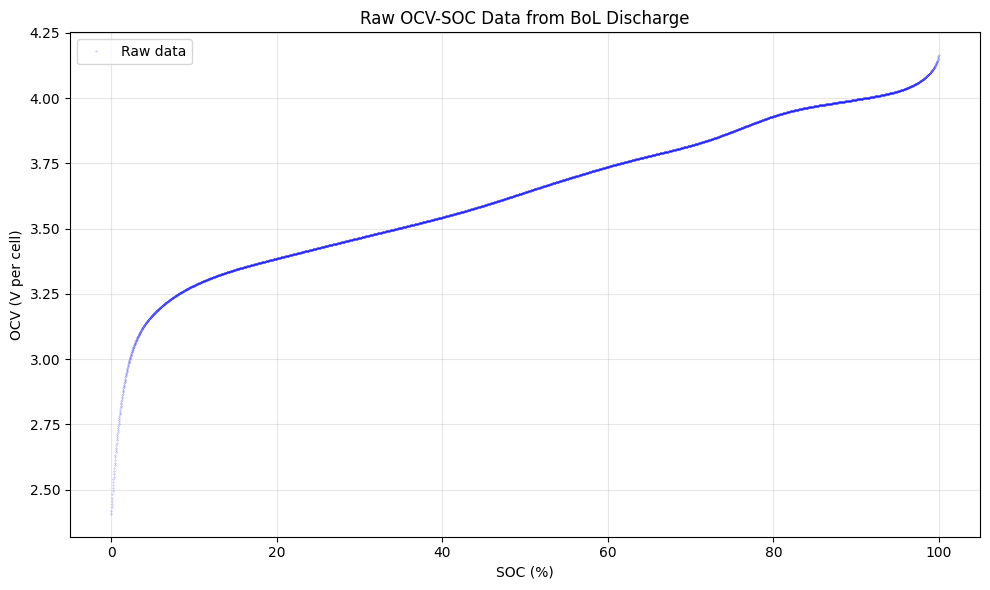

Notice the characteristic shape:
- Steep at LOW SOC (voltage drops fast when nearly empty)
- Flat in the MIDDLE (plateau region ~3.4-3.7V)
- Steep at HIGH SOC (voltage rises fast when nearly full)


In [4]:
# Plot the raw OCV vs SOC data
plt.figure(figsize=(10, 6))
plt.plot(soc_sorted * 100, ocv_sorted, 'b.', markersize=0.5, alpha=0.5, label='Raw data')
plt.xlabel('SOC (%)')
plt.ylabel('OCV (V per cell)')
plt.title('Raw OCV-SOC Data from BoL Discharge')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Notice the characteristic shape:")
print("- Steep at LOW SOC (voltage drops fast when nearly empty)")
print("- Flat in the MIDDLE (plateau region ~3.4-3.7V)")
print("- Steep at HIGH SOC (voltage rises fast when nearly full)")

## 4.4 Fit a Polynomial

`np.polyfit(x, y, degree)` finds the polynomial coefficients that best fit the data.

Let's try **different degrees** to see which one is best:

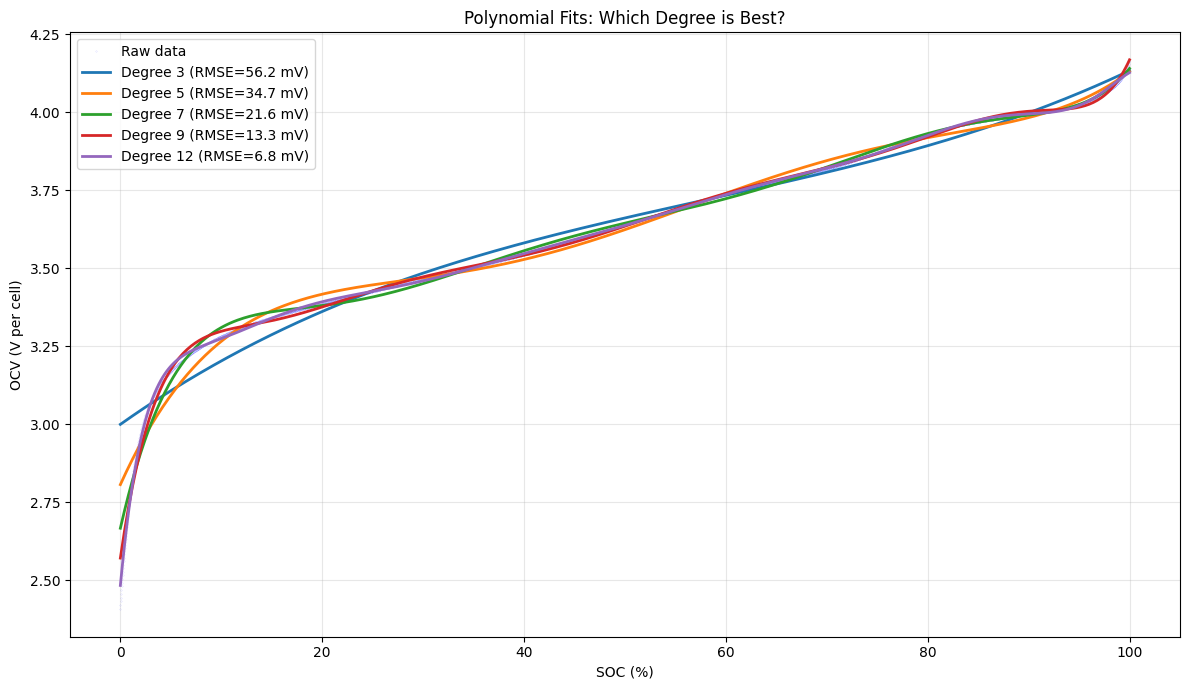

In [5]:
# Try different polynomial degrees and compare
degrees = [3, 5, 7, 9, 12]

# Fine SOC grid to evaluate polynomials on
soc_fine = np.linspace(0, 1, 500)

plt.figure(figsize=(12, 7))
plt.plot(soc_sorted * 100, ocv_sorted, 'b.', markersize=0.3, alpha=0.3, label='Raw data')

for deg in degrees:
    # Fit polynomial
    coeffs = np.polyfit(soc_sorted, ocv_sorted, deg)
    poly = np.poly1d(coeffs)
    
    # Evaluate on fine grid
    ocv_fit = poly(soc_fine)
    
    # Calculate RMSE (Root Mean Square Error)
    ocv_predicted = poly(soc_sorted)
    rmse = np.sqrt(np.mean((ocv_sorted - ocv_predicted) ** 2)) * 1000  # in mV
    
    plt.plot(soc_fine * 100, ocv_fit, linewidth=2, label=f'Degree {deg} (RMSE={rmse:.1f} mV)')

plt.xlabel('SOC (%)')
plt.ylabel('OCV (V per cell)')
plt.title('Polynomial Fits: Which Degree is Best?')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4.5 Choose Degree 9 and Fit

From the plot above, **degree 9** gives a good fit without overfitting. Let's use it:

In [6]:
# Fit degree 9 polynomial
degree = 9
coeffs = np.polyfit(soc_sorted, ocv_sorted, degree)
ocv_poly = np.poly1d(coeffs)

# Print the polynomial
print(f"Polynomial degree: {degree}")
print(f"Coefficients (highest power first):")
for i, c in enumerate(coeffs):
    power = degree - i
    print(f"  SOC^{power}: {c:+.6f}")

# Calculate fit quality
ocv_predicted = ocv_poly(soc_sorted)
rmse = np.sqrt(np.mean((ocv_sorted - ocv_predicted) ** 2))
print(f"\nRMSE = {rmse*1000:.2f} mV")
print(f"This means our polynomial is accurate to ~{rmse*1000:.0f} mV on average")

Polynomial degree: 9
Coefficients (highest power first):
  SOC^9: +3077.584675
  SOC^8: -14304.204330
  SOC^7: +28148.611047
  SOC^6: -30553.498092
  SOC^5: +19978.126033
  SOC^4: -8073.811950
  SOC^3: +1992.470125
  SOC^2: -285.976956
  SOC^1: +22.296318
  SOC^0: +2.570996

RMSE = 13.32 mV
This means our polynomial is accurate to ~13 mV on average


## 4.6 Use the Polynomial — Get OCV for Any SOC

Now we have a function! Give it a SOC, it returns a voltage:

In [7]:
# Using the polynomial is simple — just call it like a function!

def get_ocv(soc_value):
    """Get OCV for a given SOC using our polynomial."""
    return ocv_poly(soc_value)

# Test it at key SOC values
print("OCV at different SOC levels:")
print("=" * 35)
for soc_val in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]:
    ocv_val = get_ocv(soc_val)
    print(f"  SOC = {soc_val*100:5.1f}%  →  OCV = {ocv_val:.3f} V")

OCV at different SOC levels:
  SOC = 100.0%  →  OCV = 4.168 V
  SOC =  90.0%  →  OCV = 4.003 V
  SOC =  80.0%  →  OCV = 3.921 V
  SOC =  70.0%  →  OCV = 3.822 V
  SOC =  60.0%  →  OCV = 3.740 V
  SOC =  50.0%  →  OCV = 3.635 V
  SOC =  40.0%  →  OCV = 3.542 V
  SOC =  30.0%  →  OCV = 3.472 V
  SOC =  20.0%  →  OCV = 3.376 V
  SOC =  10.0%  →  OCV = 3.298 V
  SOC =   0.0%  →  OCV = 2.571 V


## 4.7 The Derivative: dOCV/dSOC

The EKF needs the **derivative** of OCV with respect to SOC.

**Why?** The EKF linearizes the model at each step. It needs to know: *"if SOC changes by a tiny bit, how much does OCV change?"* That's the derivative.

Good news: the derivative of a polynomial is also a polynomial (one degree lower)!

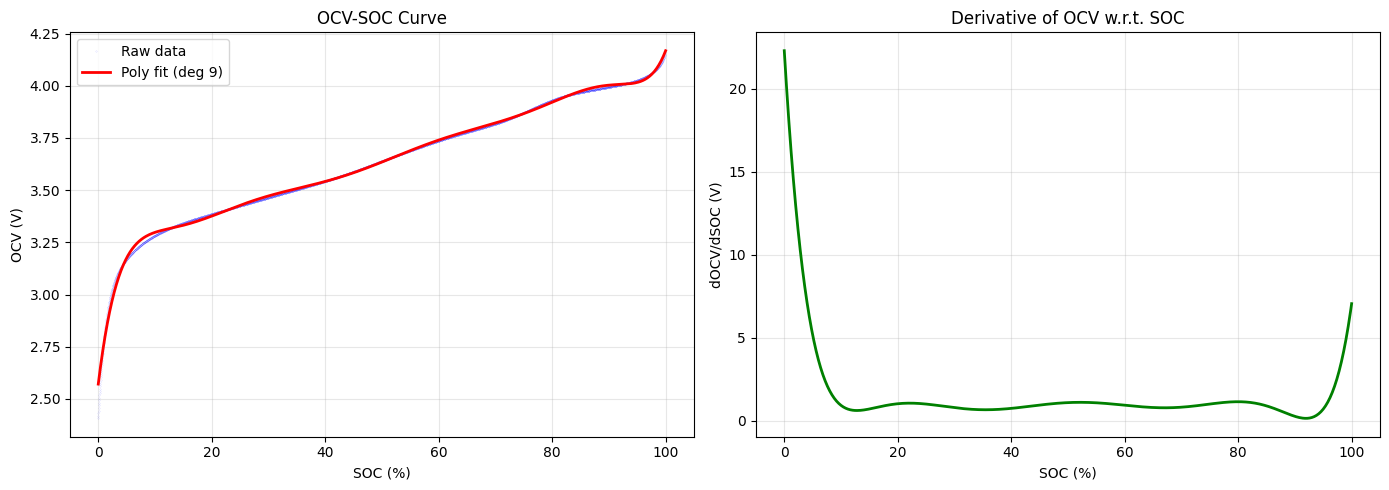

The derivative tells us:
- HIGH at low/high SOC → voltage changes fast (more sensitivity)
- LOW in the middle → voltage is flat (less sensitivity)
- This matters for EKF: corrections are bigger where the derivative is large


In [8]:
# np.polyder gives the derivative of a polynomial
docv_poly = np.polyder(ocv_poly)  # dOCV/dSOC polynomial (degree 8)

# Plot OCV and its derivative side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

soc_fine = np.linspace(0, 1, 500)

# Left: OCV vs SOC (with fit)
ax1.plot(soc_sorted * 100, ocv_sorted, 'b.', markersize=0.3, alpha=0.3, label='Raw data')
ax1.plot(soc_fine * 100, ocv_poly(soc_fine), 'r-', linewidth=2, label='Poly fit (deg 9)')
ax1.set_xlabel('SOC (%)')
ax1.set_ylabel('OCV (V)')
ax1.set_title('OCV-SOC Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: dOCV/dSOC
ax2.plot(soc_fine * 100, docv_poly(soc_fine), 'g-', linewidth=2)
ax2.set_xlabel('SOC (%)')
ax2.set_ylabel('dOCV/dSOC (V)')
ax2.set_title('Derivative of OCV w.r.t. SOC')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The derivative tells us:")
print("- HIGH at low/high SOC → voltage changes fast (more sensitivity)")
print("- LOW in the middle → voltage is flat (less sensitivity)")
print("- This matters for EKF: corrections are bigger where the derivative is large")

## 4.8 Fit Residual — How Good is Our Fit?

Let's look at the **error at each point** to see where the polynomial struggles:

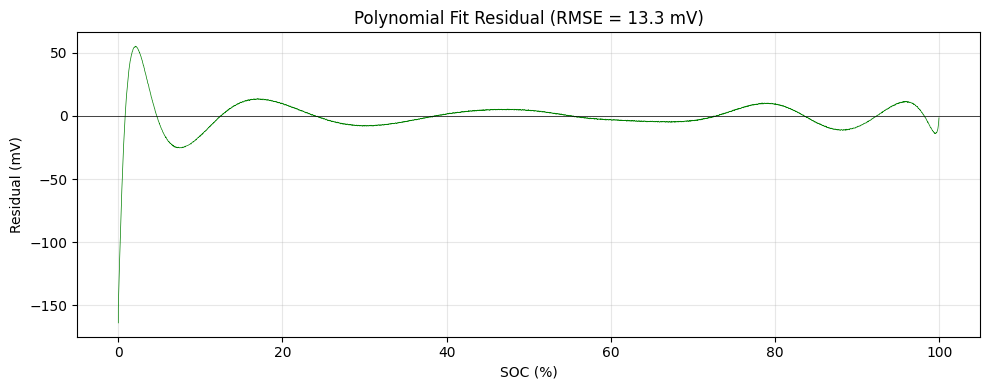

Max error: 164.0 mV
Avg error: 7.8 mV
RMSE:      13.3 mV


In [9]:
# Calculate residual (error) at each point
residual_mv = (ocv_sorted - ocv_poly(soc_sorted)) * 1000  # in millivolts

plt.figure(figsize=(10, 4))
plt.plot(soc_sorted * 100, residual_mv, 'g-', linewidth=0.5)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel('SOC (%)')
plt.ylabel('Residual (mV)')
plt.title(f'Polynomial Fit Residual (RMSE = {np.sqrt(np.mean(residual_mv**2)):.1f} mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max error: {np.max(np.abs(residual_mv)):.1f} mV")
print(f"Avg error: {np.mean(np.abs(residual_mv)):.1f} mV")
print(f"RMSE:      {np.sqrt(np.mean(residual_mv**2)):.1f} mV")

## 4.9 Summary — Ready for `ocv_soc.py`

We now have everything we need:

| What | How | Used by |
|------|-----|---------|
| **OCV(SOC)** | 9th degree polynomial | ECM model, EKF |
| **dOCV/dSOC** | Derivative of polynomial | EKF (Jacobian matrix) |

**Functions to put in `src/ocv_soc.py`:**

```python
def extract_ocv_soc_raw(voltage, soc):
    # Clean data, skip transient, sort by SOC, convert pack→cell voltage

def fit_ocv_polynomial(soc, ocv, degree=9):
    # Fit polynomial, return np.poly1d object

def get_ocv_from_soc(soc_value, ocv_poly):
    # Evaluate polynomial: OCV = poly(SOC)

def get_docv_dsoc(soc_value, ocv_poly):
    # Evaluate derivative: dOCV/dSOC = polyder(poly)(SOC)
```

**Next:** Copy these functions into `src/ocv_soc.py`, then move to Step 5 (ECM Model).